In [1]:
import tqdm
from torchvision.datasets import ImageFolder
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from transformers import AutoModelForImageClassification
from peft import LoraConfig, get_peft_model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from transformers import get_cosine_schedule_with_warmup
from torch.amp import autocast

c:\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 32
GRADIENT_ACCUMULATION_STEPS = 2
NUM_WORKERS = 8

Total_epochs = 3

In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomRotation(2),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.02,0.02)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

valid_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
train_dataset = ImageFolder(
    root=r"D:\assignment_dataset\df\train",
    transform=train_transforms
)

valid_dataset = ImageFolder(
    root=r"D:\assignment_dataset\df\valid",
    transform=valid_test_transforms
)

test_dataset = ImageFolder(
    root=r"D:\assignment_dataset\df\test",
    transform=valid_test_transforms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))
print("Test :", len(test_dataset))

Train: 319837
Valid: 39995
Test : 39996


In [5]:
model = AutoModelForImageClassification.from_pretrained(
    "microsoft/dit-base",
    num_labels=16,
    ignore_mismatched_sizes=True
)

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "query", 
        "value",
        "key",
        "output.dense",      
        "intermediate.dense", 
        "output.dense"
    ],
    lora_dropout=0.05,
    bias="none",
    modules_to_save=["classifier"]  # 16-class linear head is fully trainable
)
model = get_peft_model(model, peft_config)
model = model.to(device)

Some weights of BeitForImageClassification were not initialized from the model checkpoint at microsoft/dit-base and are newly initialized: ['beit.pooler.layernorm.bias', 'beit.pooler.layernorm.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
criterion = nn.CrossEntropyLoss(label_smoothing = 0.05)

def train_model(model, train_loader, valid_loader, optimizer, scheduler, num_epochs, stage="LoRA Fine-tuning"):    
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    # scaler = GradScaler("cuda")

    best_val_loss = float("inf")
    early_stop_count = 0
    patience = 1 

    for epoch in range(num_epochs):
        total_train_loss, total_correct, total_samples = 0.0, 0, 0
        model.train()
        
        optimizer.zero_grad() 

        for step, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            with autocast(device_type='cuda', dtype=torch.bfloat16):
                outputs = model(images)
                logits = outputs.logits
                loss = criterion(logits, labels) / GRADIENT_ACCUMULATION_STEPS

            loss.backward()

            if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0 or (step + 1) == len(train_loader):
                optimizer.step()
                optimizer.zero_grad()
                scheduler.step() 

            total_train_loss += (loss.item() * GRADIENT_ACCUMULATION_STEPS) * images.size(0)
            total_correct += (logits.argmax(1) == labels).sum().item()
            total_samples += labels.size(0)

        train_loss = total_train_loss / total_samples
        train_acc = total_correct / total_samples
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        model.eval()
        total_val_loss, total_val_correct, total_val_samples = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                logits = outputs.logits
                loss = criterion(logits, labels)

                total_val_loss += loss.item() * images.size(0)
                total_val_correct += (logits.argmax(1) == labels).sum().item()
                total_val_samples += labels.size(0)
                
        val_loss = total_val_loss / total_val_samples
        val_acc = total_val_correct / total_val_samples
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_count = 0
            torch.save(model.state_dict(), "best_dit_lora.pth")
        else:
            early_stop_count += 1
            if early_stop_count >= patience:
                print("Early stopping triggered. Model reached structural capacity.")
                break
    plt.figure(figsize=(12, 8))
    plt.plot(train_losses, label="Training Loss",color = 'red')
    plt.plot(val_losses, label="Validation Loss",color = 'blue')
    plt.xlabel("No of Epochs")
    plt.ylabel("Loss")
    plt.title("Loss per epoch")
    plt.legend()
    plt.show()
    
    plt.figure(figsize=(12, 8))
    plt.plot(train_accuracies, label="Training Accuracy",color = 'red')
    plt.plot(val_accuracies, label="Validation Accuracy",color = 'blue')
    plt.xlabel("No of Epochs")
    plt.ylabel("Accuracy")
    plt.title("Accuracy per epoch")
    plt.legend()
    plt.show()    

Epoch 1/3: Train Loss: 1.4759, Train Acc: 0.5915 | Val Loss: 0.8860, Val Acc: 0.8112
Epoch 2/3: Train Loss: 0.8136, Train Acc: 0.8330 | Val Loss: 0.6785, Val Acc: 0.8772
Epoch 3/3: Train Loss: 0.7061, Train Acc: 0.8691 | Val Loss: 0.6434, Val Acc: 0.8900


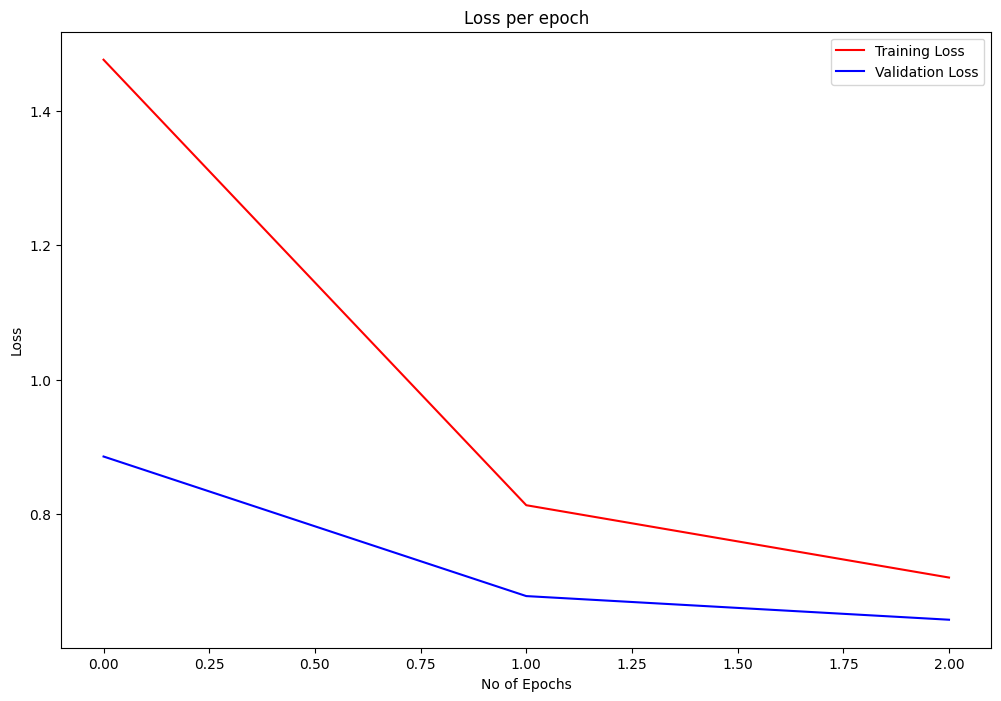

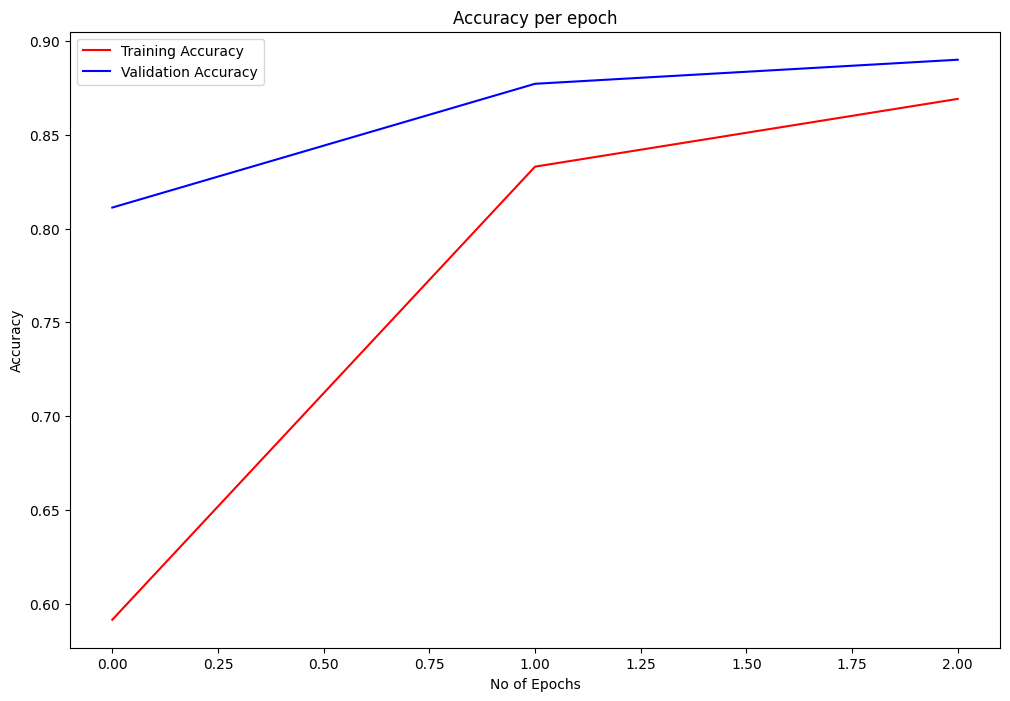

In [7]:
optimizer = optim.AdamW(model.parameters(), weight_decay = 1e-4, lr = 2e-4)
num_training_steps = (len(train_loader) // GRADIENT_ACCUMULATION_STEPS) * Total_epochs
num_warmup_steps = int(0.08 * num_training_steps)  # 8% of training spent warming up

# Initialize warm-up cosine scheduler
cosine_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)
train_model(model, train_loader, valid_loader, optimizer, cosine_scheduler, Total_epochs, stage="Training stage")

In [8]:
def evaluate_model(model, loader):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            logits = outputs.logits

            preds = logits.argmax(dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return np.array(y_true), np.array(y_pred)

In [9]:
# Perform Validation of model to plot all Validation curves 
model.load_state_dict(torch.load("best_dit_lora.pth"))
model.to(device)
y_true_val, y_pred_val = evaluate_model(model, valid_loader)

In [10]:
class_names = [
    "letter",
    "form",
    "email",
    "handwritten",
    "advertisement",
    "scientific_report",
    "scientific_publication",
    "specification",
    "file_folder",
    "news_article",
    "budget",
    "invoice",
    "presentation",
    "questionnaire",
    "resume",
    "memo"
]

In [11]:
def results(y_true, y_pred):
    print(
    classification_report(
        y_true,
        y_pred,
        digits=4
        )
    )
    print(f"\nThe accuracy score is:{accuracy_score(y_true, y_pred)}")


    print(f"\nThe precision score is:{precision_score(
        y_true,
        y_pred,
        average='macro'
    )}")

    print(f"\nThe recall score is:{recall_score(
        y_true,
        y_pred,
        average='macro'
    )}")

    print(f"\nThe f1-score score is:{f1_score(
        y_true,
        y_pred,
        average='macro'
    )}")
    
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12,10))

    sns.heatmap(
        cm,
        annot=True,
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues",
        fmt="d"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    plt.show()

              precision    recall  f1-score   support

           0     0.8946    0.9052    0.8999      2522
           1     0.8751    0.8656    0.8703      2485
           2     0.9732    0.9909    0.9820      2530
           3     0.8837    0.9482    0.9148      2451
           4     0.8049    0.7789    0.7917      2537
           5     0.9332    0.9408    0.9370      2434
           6     0.9121    0.8901    0.9010      2576
           7     0.9086    0.9000    0.9043      2430
           8     0.9388    0.9325    0.9356      2533
           9     0.9185    0.8741    0.8957      2526
          10     0.7728    0.8310    0.8009      2468
          11     0.8829    0.8331    0.8573      2516
          12     0.9616    0.9402    0.9508      2424
          13     0.9077    0.9152    0.9114      2524
          14     0.7508    0.7879    0.7689      2508
          15     0.9381    0.9095    0.9236      2531

    accuracy                         0.8900     39995
   macro avg     0.8910   

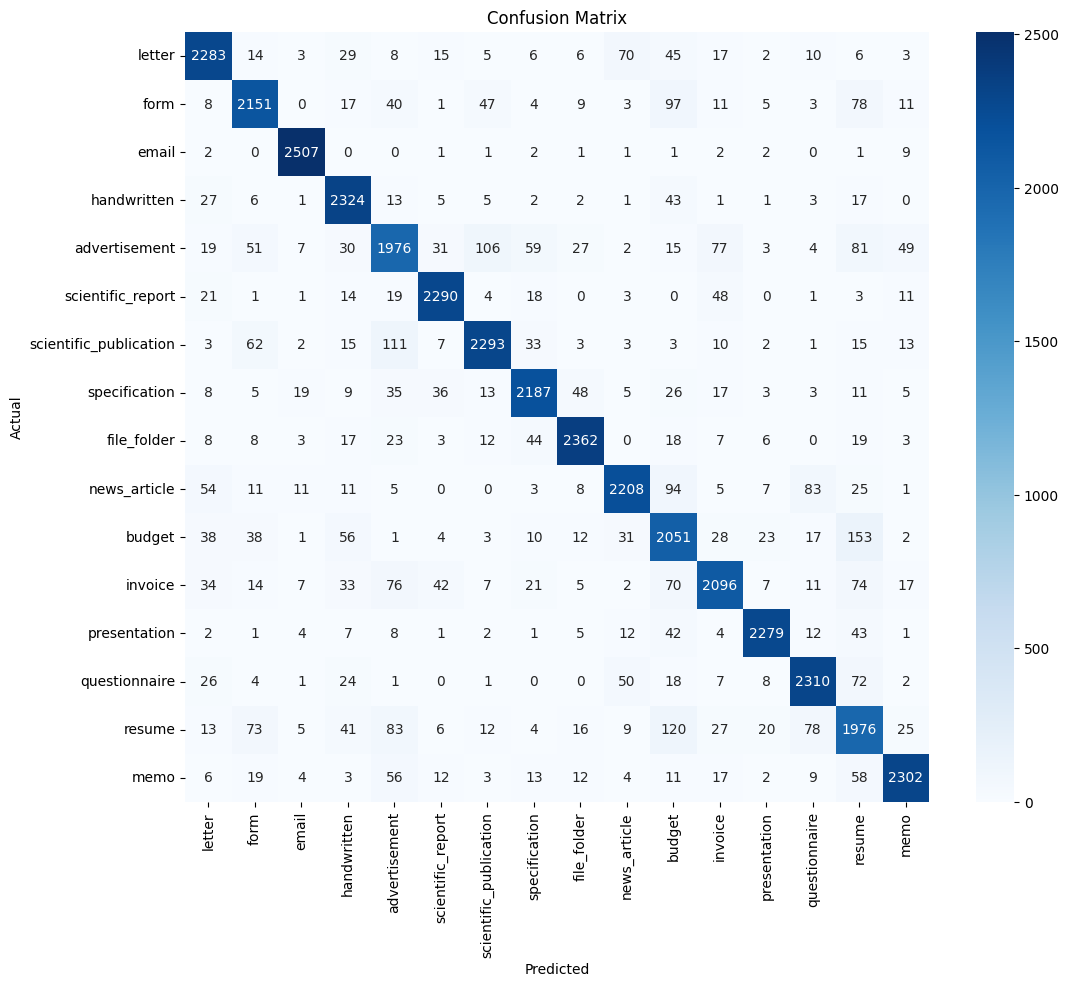

In [12]:
results(y_true_val, y_pred_val)

In [13]:
#Final Testing on test set 
y_true_test, y_pred_test = evaluate_model(model, test_loader)

              precision    recall  f1-score   support

           0     0.8991    0.9002    0.8997      2515
           1     0.8610    0.8607    0.8609      2505
           2     0.9807    0.9897    0.9852      2516
           3     0.8797    0.9581    0.9172      2527
           4     0.8050    0.7809    0.7928      2506
           5     0.9356    0.9475    0.9415      2532
           6     0.9074    0.8857    0.8964      2477
           7     0.9126    0.9022    0.9073      2464
           8     0.9363    0.9318    0.9340      2492
           9     0.9106    0.8640    0.8867      2463
          10     0.7658    0.8236    0.7937      2489
          11     0.8600    0.8251    0.8422      2435
          12     0.9699    0.9412    0.9554      2536
          13     0.9157    0.9085    0.9121      2569
          14     0.7436    0.7850    0.7638      2498
          15     0.9448    0.9009    0.9223      2472

    accuracy                         0.8881     39996
   macro avg     0.8892   

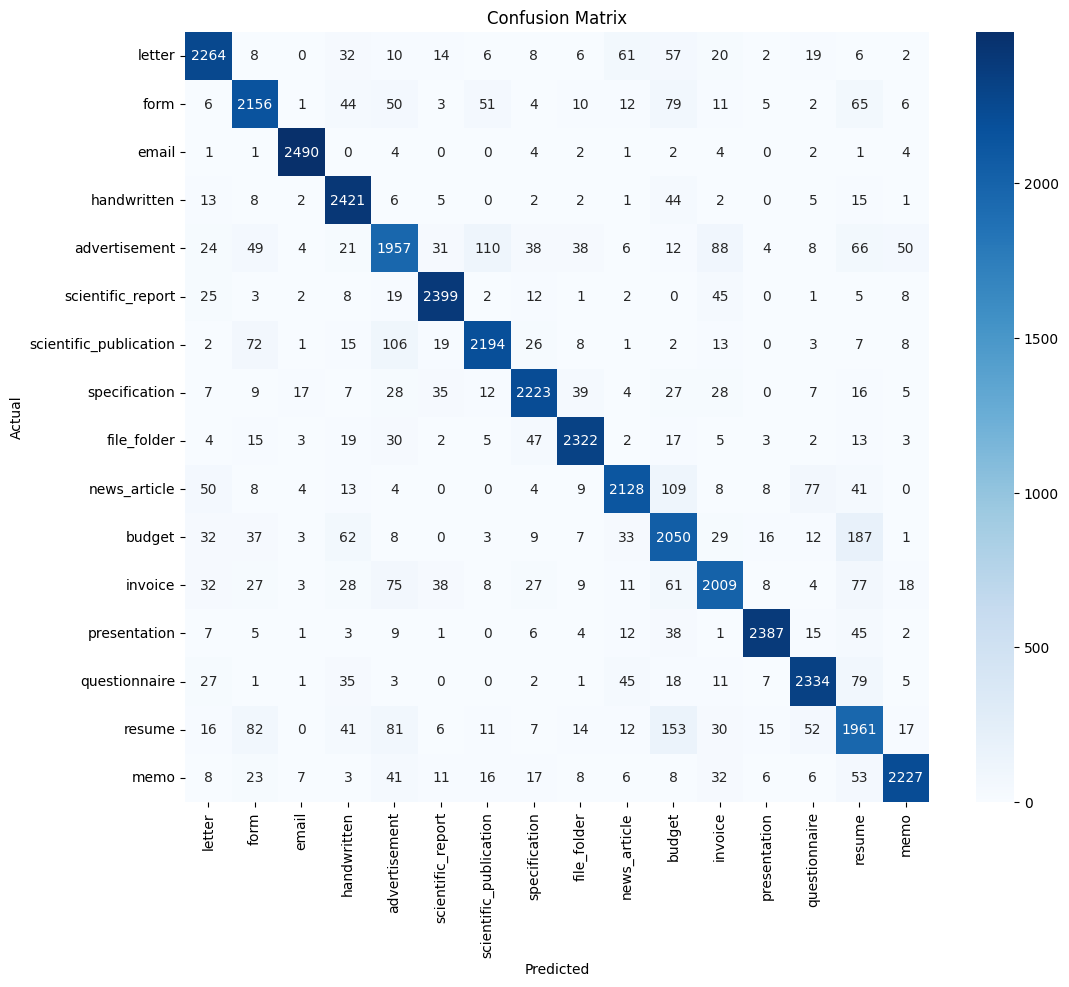

In [14]:
results(y_true_test, y_pred_test)